# 07-Vision Data Pipelines & Augmentation

In Lesson 06, we mastered the architecture of Transfer Learning by importing pretrained Enterprise Backbones. We now have a mathematical engine capable of processing complex visual data.

However, a massive architectural problem arises in production. Modern GPUs are so incredibly fast at multiplying matrices that they will finish processing a batch of images in milliseconds. If your CPU is too slow at fetching the next batch of JPGs from the hard drive and decoding them, your $15,000 GPU will literally sit idle, waiting for data. This bottleneck is called **GPU Starvation**.

To train enterprise vision models, we must engineer a high-throughput, parallel-processed Data Pipeline that loads, mathematically augments, and transfers images into GPU VRAM faster than the GPU can consume them.

Let's set up our PyTorch environment to master the flow of data.

In [1]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from skimage import data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Vision Data Pipelines Environment Ready.")

✅ PyTorch Vision Data Pipelines Environment Ready.


# 1. The Mathematics of Data Augmentation

In an ideal world, you would train your network on 100 million unique images. In reality, you might only have 5,000 images. If you show a massive Deep Neural Network the exact same 5,000 images for 100 Epochs, its millions of parameters will mathematically memorize the exact pixel values of those specific photos (Overfitting) and fail completely in production.

We solve this using **Data Augmentation**. Every single time the CPU loads an image from the hard drive, it applies a *random* sequence of mathematical transformations before sending it to the GPU.

Because the transformations are stochastically generated on the fly, the GPU never sees the exact same image matrix twice. We have artificially expanded a finite dataset into mathematical infinity.

### Geometric Transformations (Affine Matrices)

We manipulate the spatial coordinate system of the pixels.

* **Random Crop**: We take a $256 \times 256$ image and randomly slice out a $224 \times 224$ window. This forces the network to recognize the object even if it is not perfectly centered, achieving translation invariance.
* **Random Horizontal Flip**: We multiply the X-coordinates by $-1$. A coffee handle on the right mathematically becomes a coffee handle on the left.

### Photometric Transformations

We manipulate the actual light intensity values in the tensor.

* **Color Jitter**: We randomly add or subtract values from the Hue, Saturation, and Brightness channels. This forces the network to learn the physical *structural shape* of a coffee cup rather than just memorizing the exact hex code for the color of the table, allowing the model to work under harsh sunlight or dim indoor lighting.

# 2. Image Standardization (The ImageNet Stats)

As we established in Lesson 01, we divide our pixels by $255.0$ to push the tensor values between $0.0$ and $1.0$.
However, for Enterprise Backbones (like ResNet or EfficientNet), this is not enough. The pretrained weights were mathematically optimized expecting data that follows a perfect **Standard Normal Distribution** (a mean of $0$ and a standard deviation of $1$).

We must apply **Z-Score Normalization** to every single pixel ($x$):


$$x_{norm} = \frac{x - \mu}{\sigma}$$

Because we are using Transfer Learning, we **must** use the exact mathematical means and standard deviations that the researchers computed across all 1.2 million images when originally training the backbone on ImageNet:

* **ImageNet Mean ($\mu$)**: `[0.485, 0.456, 0.406]` (Red, Green, Blue)
* **ImageNet Std ($\sigma$)**: `[0.229, 0.224, 0.225]`

# 3. The Engineering Trap: Train vs. Validation Pipelines

One of the most catastrophic mistakes engineers make is applying Data Augmentation to their Validation Set.

If you randomly crop and color-jitter your validation images, your Validation Loss will bounce wildly up and down every single Epoch. You will have completely destroyed your diagnostic telemetry.

* **Training Pipeline**: Highly stochastic (randomized). Aggressive crops, flips, and color changes.
* **Validation/Production Pipeline**: Strictly deterministic. You center-crop the image perfectly and normalize it. Zero randomness is allowed.

# 4. High-Throughput DataLoader Optimization

Once the CPU has applied the mathematical transforms, it must send the batch to the GPU. We use two critical PyTorch arguments to maximize this transfer speed:

1. **`num_workers`**: Instead of the main Python process loading images sequentially, PyTorch spins up multiple background CPU cores. While the GPU is crunching Batch 1, Worker 1 is simultaneously loading Batch 2, Worker 2 is loading Batch 3, etc.
2. **`pin_memory=True`**: Normally, data moves from the Hard Drive $\rightarrow$ CPU RAM (Paged Memory) $\rightarrow$ CPU Cache $\rightarrow$ PCIe Bus $\rightarrow$ GPU VRAM. By setting `pin_memory=True`, PyTorch locks the data into a special hardware region of RAM. This allows the GPU to use **Direct Memory Access (DMA)**, pulling the data across the PCIe bus instantly without having to wake up the CPU!

# 5. Implementing the Vision Pipeline in PyTorch

Let's build a production-grade `torchvision` pipeline. We will configure the randomized training transformations, apply them sequentially to our real image, and visualize the mathematical distortions.

--- ⚙️ Data Pipelines Configured ---


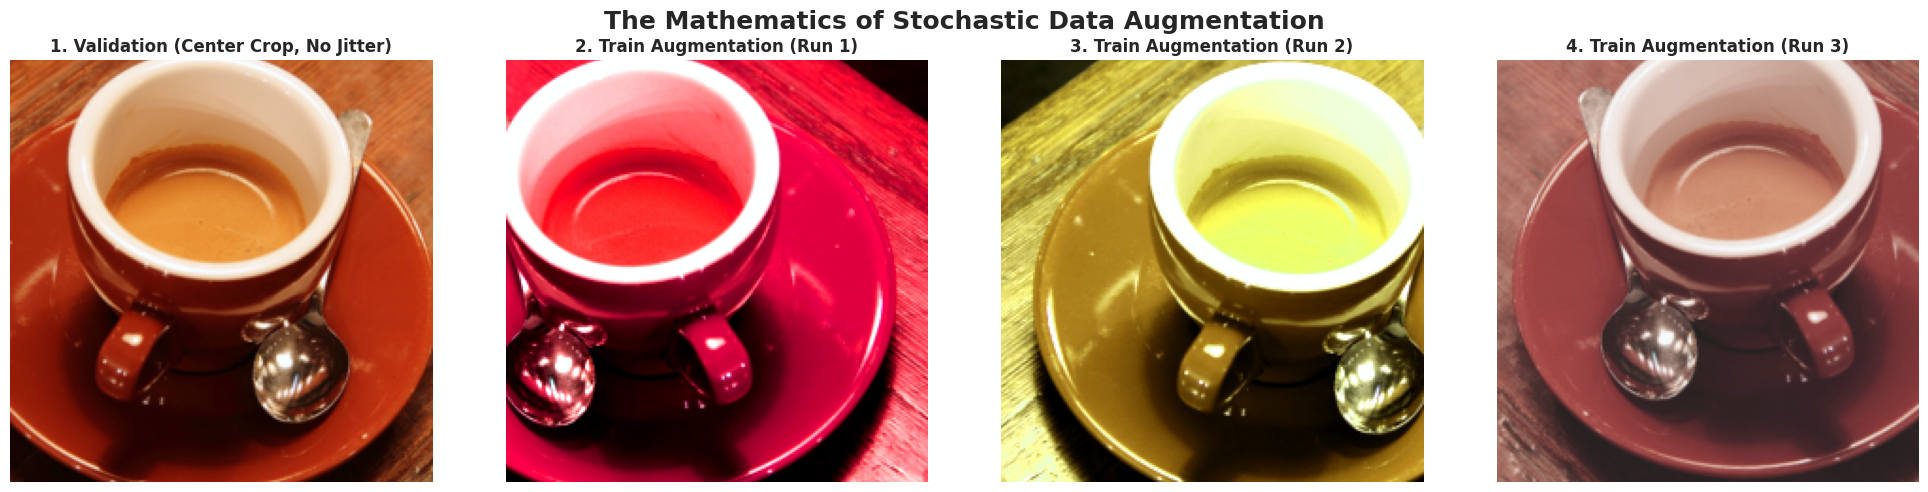


--- 💡 Engineering Insight ---
Look closely at Runs 1, 2, and 3. You passed the exact same NumPy array into the pipeline three times, but the resulting matrices are completely mathematically distinct. In Run 1, the handle might be on the left (Horizontal Flip). In Run 2, the camera is zoomed tightly onto the rim (Random Crop). In Run 3, the lighting is harsh and highly saturated (Color Jitter). The neural network is forced to learn the abstract geometry of a cup, rather than memorizing the exact pixels of the original photograph.

--- 🚀 Enterprise DataLoader Initialized ---
Batch Size:  32
CPU Workers: 4
DMA Enabled: True


In [2]:
# 1. Fetch the Target Data
numpy_coffee = data.coffee() # HWC NumPy Array

# 2. Define the ImageNet Standardization Constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# 3. Architect the TRAINING Pipeline (Randomized & Chaotic)
train_transforms = transforms.Compose([
    transforms.ToPILImage(), # Convert NumPy to PIL for transforms
    # 1. Resize the raw image to be slightly larger than our target
    transforms.Resize(256),
    # 2. Extract a random 224x224 patch (The ImageNet standard size)
    transforms.RandomCrop(224),
    # 3. 50% chance to flip the image horizontally
    transforms.RandomHorizontalFlip(p=0.5),
    # 4. Randomly tweak the lighting conditions (Brightness, Contrast, Saturation, Hue)
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    # 5. Convert to PyTorch Tensor AND scale to 0.0 - 1.0
    transforms.ToTensor(),
    # 6. Apply Z-Score Normalization
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# 4. Architect the VALIDATION Pipeline (Deterministic & Clean)
val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(256),
    # We perfectly center-crop the image. No randomness!
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("--- ⚙️ Data Pipelines Configured ---")

# 5. Visualizing Stochastic Augmentation
# Because the tensor is Z-Score Normalized, Matplotlib cannot display it (values are negative and > 1.0).
# We must mathematically reverse the normalization to visualize the exact augmented pixels.
def unnormalize_and_plot(ax, tensor, title):
    # Move channel to the end (CHW -> HWC)
    img = tensor.permute(1, 2, 0).numpy()
    # Reverse Z-Score: x_raw = (x_norm * std) + mean
    std = np.array(IMAGENET_STD)
    mean = np.array(IMAGENET_MEAN)
    img = (img * std) + mean
    # Clip to [0, 1] to fix any float rounding errors before plotting
    img = np.clip(img, 0, 1)
    
    ax.imshow(img)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

# Set up the visualization grid
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("The Mathematics of Stochastic Data Augmentation", fontsize=18, fontweight='bold')

# Plot A: Deterministic Validation Pipeline
val_tensor = val_transforms(numpy_coffee)
unnormalize_and_plot(axes[0], val_tensor, "1. Validation (Center Crop, No Jitter)")

# Plot B, C, D: Random Training Pipeline
# We pass the EXACT SAME input image through the pipeline 3 separate times.
for i in range(1, 4):
    aug_tensor = train_transforms(numpy_coffee)
    unnormalize_and_plot(axes[i], aug_tensor, f"{i+1}. Train Augmentation (Run {i})")

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look closely at Runs 1, 2, and 3. You passed the exact same NumPy array into the pipeline three times, but the resulting matrices are completely mathematically distinct. In Run 1, the handle might be on the left (Horizontal Flip). In Run 2, the camera is zoomed tightly onto the rim (Random Crop). In Run 3, the lighting is harsh and highly saturated (Color Jitter). The neural network is forced to learn the abstract geometry of a cup, rather than memorizing the exact pixels of the original photograph.")

# 6. Architecting the Enterprise DataLoader
# To prove the pipeline, we wrap our data in a Dataset and load it.
class DummyCoffeeDataset(Dataset):
    def __init__(self, img_array, transform, num_samples=100):
        self.img_array = img_array
        self.transform = transform
        self.num_samples = num_samples # Simulate having 100 images
        
    def __len__(self): return self.num_samples
    def __getitem__(self, idx): return self.transform(self.img_array), torch.tensor(1)

# Configure the High-Throughput Engine
train_loader = DataLoader(
    dataset=DummyCoffeeDataset(numpy_coffee, train_transforms),
    batch_size=32,
    shuffle=True,          # Scramble the epoch data
    num_workers=4,         # Allocate 4 dedicated CPU cores for background loading
    pin_memory=True,       # Enable Direct Memory Access (DMA) for the PCIe bus!
    drop_last=True         # Drop partial batches to prevent tensor dimension crashes
)

print("\n--- 🚀 Enterprise DataLoader Initialized ---")
print(f"Batch Size:  {train_loader.batch_size}")
print(f"CPU Workers: {train_loader.num_workers}")
print(f"DMA Enabled: {train_loader.pin_memory}")

## Real-World Use Case or Analogy:

Think of the Vision Data Pipeline like **A High-End Restaurant Kitchen**:

* **The Hard Drive (The Walk-in Fridge)**: This is where all the raw ingredients (Images) are stored. It is large, but physically walking to it, opening the door, and pulling out a steak takes a long time.
* **The GPU (The Executive Chef)**: The Chef is a master who can cook 32 steaks perfectly simultaneously in milliseconds. But if the Chef has to personally walk to the fridge to get the meat every single time, the kitchen slows to a crawl (GPU Starvation).
* **Data Augmentation (`transforms`)**: The process of washing, chopping, and seasoning the raw ingredients. Sometimes the steaks get extra pepper (Color Jitter), sometimes the fat is trimmed differently (Random Crop). This ensures the Chef is always cooking dynamic, unique meals to improve their skills.
* **CPU Workers (`num_workers=4`)**: You hire 4 dedicated Prep Cooks. They constantly run back and forth to the fridge, wash the vegetables, chop the meat, apply the seasoning, and prepare the trays *in the background* while the Chef is cooking. The Chef never has to stop working.
* **Pin Memory (`pin_memory=True`)**: The "Pass" or heating lamps right next to the Chef's station. Once the Prep Cooks finish a tray (Batch), they place it on the Pass. The Chef can grab it instantly without walking. Data moves from Paged RAM (Prep Station) to Pinned RAM (The Pass) to VRAM (The Frying Pan) with zero latency!